# Labeling

<a target="_blank" href="https://colab.research.google.com/github/pleyad/Summer-School-2026/blob/main/notebooks/XX_Labeling.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## Housekeeping (no interaction required)

In [31]:
%pip install openrouter
# Is dotenv installed?

/home/bode-wsl/projects/summerschool26/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [32]:
import os
import random
import time
from pathlib import Path
import json
import pandas as pd
from tqdm.notebook import tqdm
from openrouter import OpenRouter

from dataclasses import dataclass
tqdm.pandas()

In [33]:
IN_COLAB = 'COLAB_RELEASE_TAG' in os.environ
DATA_DIR = Path('/content/drive/MyDrive/ZBSummerSchool26/data') if IN_COLAB else Path('../data')
MODEL_NAME = "openai/gpt-5.4-mini"

In [34]:
def confirm(question: str = "Do you want to execute this cell?"):
    while True:
        response = input(f"{question} (y/n): ").lower()
        if response in ["y", "yes"]:
            return True
        elif response in ["n", "no"]:
            return False
        else:
            print("Please enter 'y' or 'n'.")

## Setup (Interaction required)

### Load the data

In [35]:
### ⬇️⬇️⬇️ 💽 Adjust here if you want to continue with your own query
CORPUS_NAME = "armenpflege"
LOAD_OWN_DATA = True
YOUR_NAME = "niclas"
SEPARATOR = ";"  # Separator for the CSV file, e.g., ";" for semicolon, "," for comma
### ⬆️⬆️⬆️

In [36]:
if IN_COLAB and LOAD_OWN_DATA: # and confirm("Do you want to mount your Google Drive?"):
    from google.colab import drive
    drive.mount('/content/drive')
    os.makedirs(DATA_DIR, exist_ok=True)

#### <img src="https://cdn.simpleicons.org/googledrive" alt="💾" width=16> Load your own data from Google Drive

#### <img src="https://cdn.svglogos.dev/logos/google-drive.svg" alt="💾" width=16> Load your own data from Google Drive

In [37]:
if LOAD_OWN_DATA:
    # RAWDATA_PATH = DATA_DIR / f"{CORPUS_NAME}.filtered.parquet" # Use data from filtering module
    # raw_df = pd.read_parquet(RAWDATA_PATH)

    # SENTENCES_PATH = DATA_DIR / f"{CORPUS_NAME}.filtered.sentences.parquet" # Use data from filtering module
    # sentences_df = pd.read_parquet(SENTENCES_PATH)

    # raw_df = raw_df.join(sentences_df, on="id")

    LABELS_PATH = DATA_DIR / f"{CORPUS_NAME}.filtered.pp.label.{YOUR_NAME}.csv" # Use data from filtering module
    labels_df = pd.read_csv(LABELS_PATH, index_col="id", sep=SEPARATOR)

In [38]:
if not LOAD_OWN_DATA:
    # RAWDATA_ORIGIN_URL = "https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/armensteuer_and_similars.filtered.csv" 
    # raw_df = pd.read_csv(RAWDATA_ORIGIN_URL, index_col="id")

    # RAWDATA_ORIGIN_URL = "https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/armensteuer_and_similars.filtered.parquet"
    # print(f"Loading raw data ...", end="\r")
    # raw_df = pd.read_parquet(RAWDATA_ORIGIN_URL)

    # SENTENCES_URL = "https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/armensteuer_and_similars.filtered.sentences.parquet"
    # print(f"Loading sentences data ...", end="\r")
    # sentences_df = pd.read_parquet(SENTENCES_URL)

    LABELS_PATH = "https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/armenpflege.filtered.pp.label.niclas.csv"
    labels_df = pd.read_csv(LABELS_PATH, index_col="id", sep=SEPARATOR)

    # raw_df = raw_df.join(sentences_df)

In [ ]:
# ⚙️ Developer 

def rename_labels(label):
    mapping = {
            "Protokollarischer Bericht": "Protokollarischer Bericht", #"Bericht", #"Protokollarischer Bericht",
            "Meinungsartikel": "Meinungsartikel",
            "Einzelfall": "Einzelfall",
            "Budgetbericht": "Budgetbericht",#"Bericht", #"Budgetbericht",
            "Budget": "Budgetbericht", #"Bericht", #"Budgetbericht",
            "Sachdarstellung": "Sachdarstellung"
        }
    return mapping.get(label, label)

labels_df["label"] = labels_df["label"].apply(rename_labels)

### Enable LLM interaction

In [40]:
from openrouter import OpenRouter
import os
import dotenv
dotenv.load_dotenv()

with OpenRouter(
  # api_key=API_KEY,
  api_key=os.getenv("OPENROUTER_API_KEY"),
) as client:
  response = client.chat.send(
    model=MODEL_NAME,
    messages=[
      {
        "role": "user",
        "content": "What is the meaning of life?"
      }
    ]
  )

print(response.choices[0].message.content)

There isn’t one universally agreed, provable meaning of life.

Different people answer it in different ways:

- **Biology:** to survive, reproduce, and pass on life
- **Religion:** to serve God, grow spiritually, or fulfill a divine purpose
- **Philosophy:** to create your own meaning through values, relationships, and choices
- **Humanism:** to reduce suffering, help others, and build a better world

A practical answer is: **life’s meaning is something you make through what you care about, who you love, and how you live.**

If you want, I can also give you:
1. a philosophical answer,  
2. a spiritual/religious answer, or  
3. a very short answer.


### 

## Introduction to Prompting

## Hands-on:
Now try the following things:

1.   Change the user prompt and re-run the request.
2.   Change the system prompt to something completely random and re-run the request.

### Temperature and top-p
Let's go through each of these arguments one-by-one. Below you will see API calling code for the LLM with a slightly more complex prompt. Try out requests to this LLM where you:


1.   Vary the temperature parameter.
2. Vary the top-p parameter.

Your task is try to get the funniest and weirdest response possible from the model.

In order to prevent too excessive an output (and to protect our OpenAI budget!) we'll limit the output to a maximum of 50 tokens using the `max_tokens` argument; please do not change this.

In [41]:
# ⬇️⬇️⬇️ Adjust the system and user prompts here to see how it affects the output
longer_system_prompt = (
    "You are a political text classifier. Given a social media post, return a JSON object "
    "with exactly four fields: "
    "\"topic\" (a short label for the main topic, e.g. 'economy', 'healthcare', 'immigration'), "
    "\"sentiment\" (one of: 'positive', 'negative', 'neutral'), and "
    "\"is_political\" (true or false). "
    "Return only the JSON object, nothing else."
)
longer_user_prompt = (
    "Post: 'Can't believe they're cutting the healthcare budget again while giving tax breaks "
    "to billionaires. This government doesn't care about ordinary people.'"
)
# ⬆️⬆️⬆️

In [42]:
with OpenRouter(
  api_key=os.getenv("OPENROUTER_API_KEY"),
) as client:
    response = client.chat.send(
        model=MODEL_NAME,
        messages=[
        {"role": "system", "content": longer_system_prompt},
        {"role": "user", "content": longer_user_prompt}
        ],
        max_tokens=50,

        # ⬇️⬇️⬇️ Adjust these parameters to see how it affects the output
        temperature=1, # 0-1
        top_p=0.1 # 0-1
        # ⬆️⬆️⬆️
    )

output_text = response.choices[0].message.content  # take the output and extract the text response only

# parse and pretty-print the JSON output
parsed = json.loads(output_text)
print(json.dumps(parsed, indent=2))

{
  "topic": "healthcare",
  "sentiment": "negative",
  "is_political": true
}


## Inspect your gold standard

In [43]:
labels_df[labels_df["label"].notna()].value_counts(subset=["label"])

label                    
Protokollarischer Bericht    40
Meinungsartikel              13
Einzelfall                   13
Budgetbericht                 7
Sachdarstellung               7
Name: count, dtype: int64

## Assess labels and classification schemes by comparing the results of two human coders

The code in this chapter needs the labels of two different people.
We have prepared two labellers


In [44]:
NICLAS_PATH = "https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/armenpflege.filtered.pp.label.niclas.csv"
niclas_df = pd.read_csv(NICLAS_PATH, index_col="id", sep=SEPARATOR)
niclas_df = niclas_df[niclas_df["label"].notna()]

# ELIAS_PATH = "https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/armenpflege.filtered.pp.label.elias.csv"
ELIAS_PATH = "https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/armenpflege.filtered.pp.label.niclas.csv"
elias_df = pd.read_csv(ELIAS_PATH, index_col="id", sep=SEPARATOR)
elias_df = elias_df[elias_df["label"].notna()]

# Only keep the entries that both annotators labelled
common_ids = sorted(set(niclas_df.index) & set(elias_df.index))
niclas_df = niclas_df.loc[common_ids]
elias_df = elias_df.loc[common_ids]

def rename_labels(label):
    mapping = {
            "Protokollarischer Bericht": "Protokollarischer Bericht", #"Bericht", #"Protokollarischer Bericht",
            "Meinungsartikel": "Meinungsartikel",
            "Einzelfall": "Einzelfall",
            "Budgetbericht": "Budgetbericht",#"Bericht", #"Budgetbericht",
            "Budget": "Budgetbericht", #"Bericht", #"Budgetbericht",
            "Sachdarstellung": "Sachdarstellung"
        }
    return mapping.get(label, label)

niclas_df["label"] = niclas_df["label"].apply(rename_labels)
elias_df["label"] = elias_df["label"].apply(rename_labels)

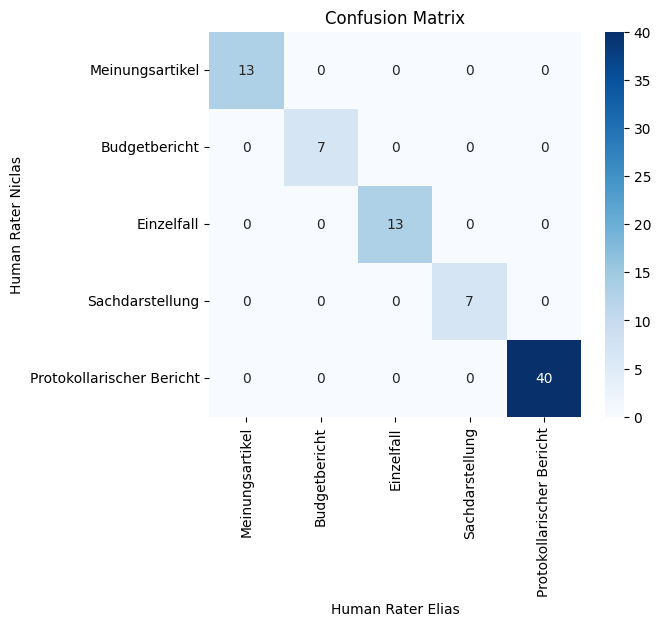

Cohen's Kappa: 1.0000
Matthews Correlation Coefficient: 1.0000


In [45]:
from sklearn.metrics import confusion_matrix, cohen_kappa_score, matthews_corrcoef
from matplotlib import pyplot as plt
import seaborn as sns

def evaluate_rater_agreement(labels_1: pd.Series, name_1: str, labels_2: pd.Series, name_2: str):

    mask = labels_1.notna() & labels_2.notna()
    labels_1 = labels_1[mask]
    labels_2 = labels_2[mask]

    labels = list(set(labels_1) | set(labels_2))

    cm = confusion_matrix(labels_1, labels_2, labels=labels)
    kappa = cohen_kappa_score(labels_1, labels_2, labels=labels)
    mcc = matthews_corrcoef(labels_1, labels_2)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.xlabel(name_2)
    plt.ylabel(name_1)
    plt.title('Confusion Matrix')
    plt.show()
    print(f"Cohen's Kappa: {kappa:.4f}")
    print(f"Matthews Correlation Coefficient: {mcc:.4f}")

evaluate_rater_agreement(niclas_df["label"], "Human Rater Niclas", elias_df["label"], "Human Rater Elias")

In [46]:
# Show disagreemnts
niclas_df[niclas_df["label"] != elias_df["label"]]


,url,year,media_title,pseudo_paragraph,label
id,,,,,


## Develop an LLM Labeller

### Split the labelled data

We split the labelled data into two smaller datasets:
- tuning set
- evaluation set

We use the tuning set to repeatedly query the LLM and 'tune' our prompt.
If something gets misclassified with the tuning set, we try to steer the LLM in a better direction.
However, we need to remain general enough in our prompt so that we are not only optimizing for the tuning set, but for all data.

Once we are happy with the results on the tuning set, we evaluate **once** with the evaluation set and don't change the prompt any further!

The resulting metrics give us an impression for how well the model will behave on the whole dataset.

In [47]:
unlabelled_df = labels_df[labels_df["label"].isna()].copy() 
gold_df = labels_df[~labels_df["label"].isna()].copy()

In [48]:
from sklearn.model_selection import train_test_split

sample_size = len(gold_df)
evaluation_size = min(20, sample_size // 2)
tuning_size = sample_size - evaluation_size

sample_df = gold_df.sample(sample_size, random_state=42)
evaluation_df, tuning_df = train_test_split(
    sample_df,
    test_size=tuning_size,
    random_state=42,
    stratify=sample_df["label"],
)

print("Evaluation set label distribution:")
print(evaluation_df["label"].value_counts())
print()

print("Tuning set label distribution:")
print(tuning_df["label"].value_counts())

Evaluation set label distribution:
label
Protokollarischer Bericht    10
Einzelfall                    3
Meinungsartikel               3
Sachdarstellung               2
Budgetbericht                 2
Name: count, dtype: int64

Tuning set label distribution:
label
Protokollarischer Bericht    30
Einzelfall                   10
Meinungsartikel              10
Budgetbericht                 5
Sachdarstellung               5
Name: count, dtype: int64


### Define the labels for the LLM

Label scheme for Armenpflege

Proven too unreliable:

![categories_bad](../assets/armenpflege_categories.excalidraw.png)

Hopefully better:

![categories_better](../assets/armenpflege_kategoriensystem.excalidraw.png)

In [49]:
# ⬇️⬇️⬇️ Adjust the categories according to your data
categories = {
    "Protokollarischer Bericht": "The article is an objective formal report of a political or social event.",
    # "Bericht": "The article is an objective formal report of a political or social event. This label is also used if the article reports on public speakers that may themselves use opionated language, but the article itself does not express an opinion.",
    "Meinungsartikel": "The article expresses a subjective opinion or stance of the author, and not only of other individuals mentioned in the article.",
    "Einzelfall": "The article describes a specific individual case of a person or a singular institution without making broader generalizations. Persons may either be people donating to charity or people relying on charity. The mention of singular politicians or speakers is no Einzelfall.",
    "Budgetbericht": "The article objectively reports on political budget proceedings without expressing an opinion.",
    "Sachdarstellung": "The article objectively presents factual information that is not connected to a specific year or event, especially not in local politics. Examples are explainers and background pieces that provide context for political events without expressing an opinion."
}
# ⬆️⬆️⬆️

In [50]:
# This response format forces the model to always return an expected structure
response_format = {
            "type": "json_schema",
            "json_schema": {
                "name": "armenpflege_classification",
                "strict": True,
                "schema": {
            "type": "object",
            "properties": {
                "reasoning": {
                    "type": "string"
                },
                "label": {
                    "type": "string",
                    "enum": list(categories.keys())
                },
            },
            "required": ["label", "reasoning"],
            "additionalProperties": False
        }
    }
}

def get_model_response(post: str) -> dict:
    system_prompt = (

        # ⬇️⬇️⬇️ Adjust the system prompt to guide the model's response
        "You are a classifier for historical articles on 'Armenpflege'."
        "You are given a text excerpt from a historical news page."
        "The OCR can be faulty, and the text may contain sentences from other articles at the start and end. "
        "Only classify the thematic cluster around 'Armenpflege' in the middle of the text, not the sentences at the start and end. "
        "Your task is to classify the article into one of the following categories based on its content and style. "
        # ⬆️⬆️⬆️

        "You must return a JSON object with the following structure with exactly two fields: "
        "\"reasoning\" (a very brief explanation of why the post was classified with the chosen label as opposed to the next plausible label, few words, no verbs). "
        "\"label\" (one of: "
        + ", ".join([f"'{cat}' ({desc})" for cat, desc in categories.items()])
        + "), "
        "Return only the JSON object, nothing else."

        # ⬇️⬇️⬇️ Add examples for few-shot learning
        # "Example: "
        # ⬆️⬆️⬆️
    )
    user_prompt = f"Post: '{post}'"

    with OpenRouter(
      api_key=os.getenv("OPENROUTER_API_KEY"),
    ) as client:
        response = client.chat.send(
            model=MODEL_NAME,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            response_format=response_format,
            max_tokens=80,
        )

    prediction = json.loads(response.choices[0].message.content)

    return prediction

get_model_response("25 beträgt, wird Kenntnis genommen. An die Kosten der Rodung und Urbarisierung der « Esclhaldc », Gemeinde Muttenz, wird ein Staatsbeitrag bewilligt. Vom vorliegenden Bericht der durchgeführten Gewerbehilfe des Schweizerischen Verbandes der gewerblichen Bürgschaftsgenossenschaften wird Kenntnis genommen. Die Wahlen eines Mitgliedes des Gemeinderates Lausen, eines Mitgliedes der Armenpflege Giebenach und einer Primarlehrcrin für die Gemeinden Arisdorf und Hersberg werden bestätigt. Sanierung des Kirchen- und Schulgutes —st. Seit mehreren Jahren geht das Vermögen des Kirchen- und Schulgutes und damit auch der Zinsertrag unaufhaltsam zurück. Innert zwanzig Jahren hat des Vermögen um 300 911 Fr. abgenommen und betrug 1940 noch 2 986 910 Fr.; an Zinsen stehen 66 572 Fr. weniger zur Verfügung.")

{'reasoning': 'Amts-/Sitzungsbericht; Armenpflege nur Wahlpunkt, sonst sachlich',
 'label': 'Protokollarischer Bericht'}

In [51]:
def safe_get_model_response(article: str):
    try:
        prediction = get_model_response(article)
        label = prediction.get("label", "error")
        reasoning = prediction.get("reasoning", "No reasoning provided.")
        return pd.Series([label, reasoning])
    except Exception as e:
        print(f"Error processing article: {e}")
        return pd.Series(["error", str(e)])

tuning_df[["predicted_label", "reasoning"]] = tuning_df["pseudo_paragraph"].progress_apply(safe_get_model_response)

  0%|          | 0/60 [00:00<?, ?it/s]

In [52]:
tuning_df

,url,year,media_title,pseudo_paragraph,label,predicted_label,reasoning
id,,,,,,,
FedGazDe-1959-06-25-a-i0002,https://impresso-project.ch/app/issue/FedGazDe...,1959,Bundesblatt,"Bedürftige invalide Versicherte, die derart hi...",Protokollarischer Bericht,Sachdarstellung,"Sachtext zu Hilflosenentschädigung, allgemeine..."
NZZ-1882-10-11-b-i0002,https://impresso-project.ch/app/issue/NZZ-1882...,1882,Neue Zürcher Zeitung,"Hrch., Gemeindrath, Egg. 31) Eschmann Iohs., K...",Protokollarischer Bericht,Protokollarischer Bericht,"Namensliste, amtliche Wahl-/Funktionsaufzählun..."
NZZ-1944-06-09-a-i0001,https://impresso-project.ch/app/issue/NZZ-1944...,1944,Neue Zürcher Zeitung,Vermehrte eingänge und sittsames Haushalten wi...,Budgetbericht,Budgetbericht,"knappe Rechnungsmitteilung, Fondszuweisungen; ..."
NZZ-1877-06-27-a-i0122,https://impresso-project.ch/app/issue/NZZ-1877...,1877,Neue Zürcher Zeitung,Durch dasselbe werden bes Oberkommandanten uns...,Einzelfall,Einzelfall,"Gemeindliche Zuschrift, Fallprüfung; keine all..."
FZG-1962-03-31-a-i0029,https://impresso-project.ch/app/issue/FZG-1962...,1962,Freiburger Nachrichten,Die Gemeindeversammlung. Die verschiedenen Rec...,Budgetbericht,Budgetbericht,"Gemeinderechnung, Armenpflege als Posten; sach..."
armeteufel-1910-06-05-a-i0011,https://impresso-project.ch/app/issue/armeteuf...,1910,Arme Teufel,z n verbreitend Sonntags besticht sie Kranke u...,Meinungsartikel,Meinungsartikel,"polemische Zuspitzung, öffentliche Armenpflege..."
DTT-1941-02-11-a-i0014,https://impresso-project.ch/app/issue/DTT-1941...,1941,Die Tat,Die kantonale Altersversicherung in der Einuel...,Protokollarischer Bericht,Sachdarstellung,"Gesetzesberatung zur Altersversicherung, Sachd..."
obermosel-1933-12-22-a-i0033,https://impresso-project.ch/app/issue/obermose...,1933,Obermosel-Zeitung,Des Weilern wurde ihm der Führerschein für die...,Einzelfall,Einzelfall,"Fallbericht, einzelne Familie und Person im Mi..."
NZZ-1880-09-21-c-i0002,https://impresso-project.ch/app/issue/NZZ-1880...,1880,Neue Zürcher Zeitung,daß dic Aufsichtsbehörden dic Ueberzeugung von...,Meinungsartikel,Sachdarstellung,Sachliche Regelung zur Aufsicht über Beurlaubt...


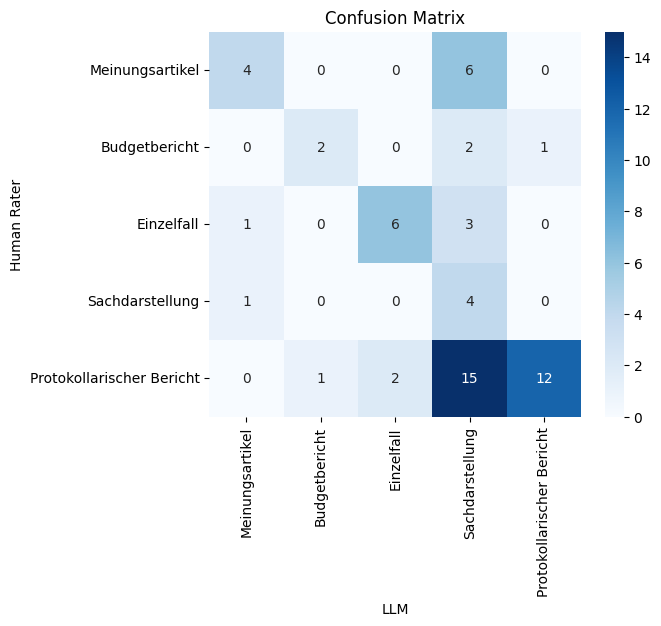

Cohen's Kappa: 0.3391
Matthews Correlation Coefficient: 0.4044


In [53]:
evaluate_rater_agreement(tuning_df["label"], "Human Rater", tuning_df["predicted_label"], "LLM")


#### Inspect disagreements

In [54]:
tuning_df[tuning_df["label"] != tuning_df["predicted_label"]][["pseudo_paragraph", "label", "predicted_label", "reasoning"]]

,pseudo_paragraph,label,predicted_label,reasoning
id,,,,
FedGazDe-1959-06-25-a-i0002,"Bedürftige invalide Versicherte, die derart hi...",Protokollarischer Bericht,Sachdarstellung,"Sachtext zu Hilflosenentschädigung, allgemeine..."
DTT-1941-02-11-a-i0014,Die kantonale Altersversicherung in der Einuel...,Protokollarischer Bericht,Sachdarstellung,"Gesetzesberatung zur Altersversicherung, Sachd..."
NZZ-1880-09-21-c-i0002,daß dic Aufsichtsbehörden dic Ueberzeugung von...,Meinungsartikel,Sachdarstellung,Sachliche Regelung zur Aufsicht über Beurlaubt...
DTT-1965-06-18-a-i0350,Der Grossstaat bietet seinen aktiven Angehörig...,Meinungsartikel,Sachdarstellung,"Allgemeine staatskundliche Darstellung, kein E..."
FedGazDe-1872-04-27-a-i0004,April 1872). Der Bundesrath hat sich veranlass...,Protokollarischer Bericht,Sachdarstellung,"Amtliches Kreisschreiben, statistische Erhebun..."
DTT-1955-05-09-a-i0108,Zürichs Lohnverhältnisse sind nicht im gleiche...,Meinungsartikel,Sachdarstellung,"Fachliche Diskussion über Armenpflege, allgeme..."
handelsztg-1877-03-08-a-i0003,Regierung») Andere Einnahmen Unterstützungen a...,Protokollarischer Bericht,Sachdarstellung,"Sachliche Vereinsrechnung, Hilfsmaßnahmen, kei..."
DTT-1973-12-25-a-i0146,Der Verein will im kommenden Wahlkampf einen e...,Protokollarischer Bericht,Sachdarstellung,"Sachlicher Verwaltungsbericht, keine Wertung; ..."
luxwort-1942-04-21-a-i0049,Nicht Armenpflege sondern Volkswohlfahrt Hilfs...,Sachdarstellung,Meinungsartikel,"Propagandistische Programmschrift, keine Einze..."


Die trauernden Hinterbliebenen. Diele Mutter Ursula ist jene Klosterfrau, die unter den Augen de « deutschen Kanonen » Kaisers, Wilhelm des „ Frommen, auf den Bahnhof in Köln getragen wurde, um in die Verbannung gebracht zu Weiden. England Der Humanitätsschwindcl, der in ber Schwei z in Folge der Prügel, welche ber ausgelassene Schriftsetzer Riniler von der Urncr Polizei erhalten Halle, sogar einen Verfassungspara « graphen schuf, scheint in England seine besten Tage hinter stch zu haben. Die Armenpflege Anstalt der Stadt Birmingham, welche nebe ^, Liverpool cin Hauptsth ber Trunkenheit und Nohheit ist, petitionirt um Wiedereinführung der körperlichen Züchtigung. In England mehren sich überhaupt dic Stimmen, welche die humanen Strafmittel der Neuzeit wieder abschaffen wollen. — Dic „ Times, das Londoner Weltblatt, wird nun auch einen besondern Telcgraphendraht nach Verlin erhalten. Paris soll das Hauptquartier für Nachrichten aus Frankreich, Spanien, Italien und Aegyp.